# Atelier Matplotlib

## Structure du projet
### 4. Installer et importer matplotlib et pandas

In [174]:
import matplotlib.pyplot as plt
import pandas as pd

### 5. Importer mesures_capteurs.csv dans le dataframe df

In [175]:
df = pd.read_csv('../data/mesures_capteurs.csv')
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Partie 1 – Graphique linéaire (Line Plot) 
### 1. Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.

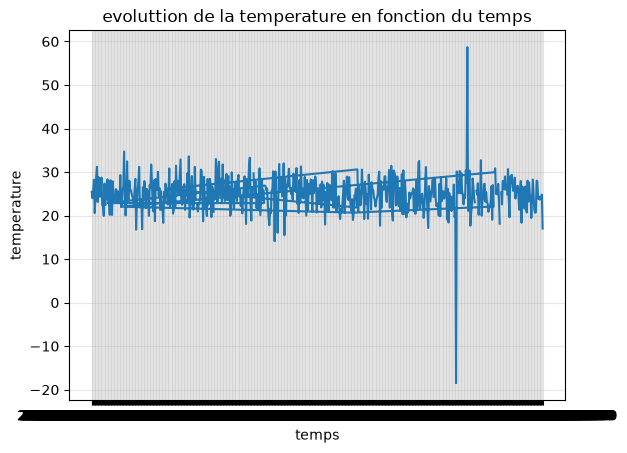

In [176]:
df = pd.read_csv('../data/mesures_capteurs.csv')
fig, ax = plt.subplots()
ax.plot(df['date_heure'],df['temperature'])
plt.title("evoluttion de la temperature en fonction du temps")
plt.xlabel("temps")
plt.ylabel("temperature")
plt.grid(True,alpha=0.3)
plt.show()

### 2. Identifier visuellement les valeurs qui semblent anormales

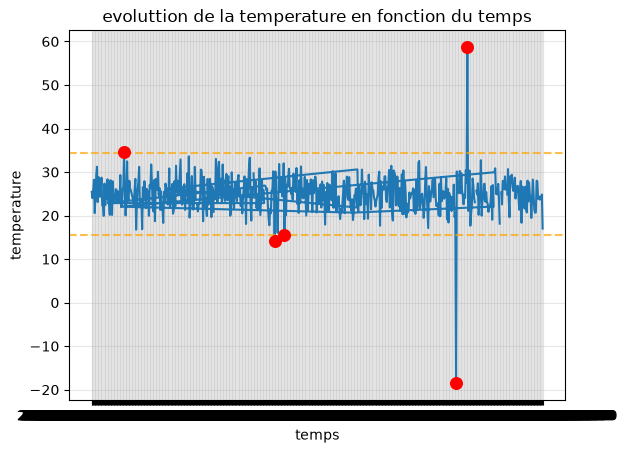

In [177]:
Q1 = df['temperature'].quantile(0.25)
Q3 = df['temperature'].quantile(0.75)
IQR = Q3 - Q1
seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

anomalies = df[(df['temperature'] < seuil_bas) | (df['temperature'] > seuil_haut)]

fig, ax = plt.subplots()
ax.plot(df['date_heure'],df['temperature'])
plt.scatter(anomalies['date_heure'], anomalies['temperature'], color='red', s=70, label='Valeurs anormales', zorder=5)
plt.axhline(seuil_bas, color='orange', linestyle='--', alpha=0.7, label='Seuil bas')
plt.axhline(seuil_haut, color='orange', linestyle='--', alpha=0.7, label='Seuil haut')

plt.title("evoluttion de la temperature en fonction du temps")
plt.xlabel("temps")
plt.ylabel("temperature")
plt.grid(True,alpha=0.3)
plt.show()



### Explication : Le graphique montre une évolution générale de la température assez régulière, avec quelques écarts brutaux visibles sur la courbe. Ces pics et chutes extrêmes correspondent aux valeurs anormales identifiées en rouge et peuvent refléter des anomalies de mesure.

## Partie 2 – Diagramme en barres (Bar Chart) 
### 1. Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments

In [178]:
# Calculer la consommation moyenne des bâtiments
consommation_batiment = df.groupby('batiment')['consommation'].mean()
print(consommation_batiment)

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64


### 2. Comparer graphiquement la consommation moyenne des bâtiments

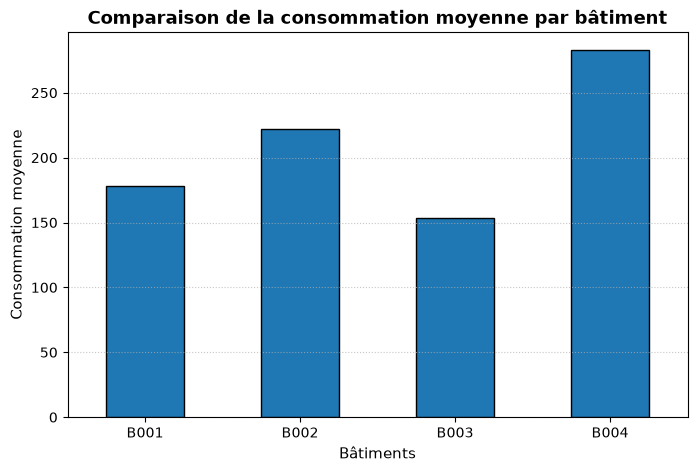

In [179]:
# Création d'une figure de dimension 8x5
plt.figure(figsize=(8, 5))

# Tracé du diagramme en barres verticales
consommation_batiment.plot(kind='bar', edgecolor='black')

# Configuration du titre et des axes
plt.title("Comparaison de la consommation moyenne par bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Bâtiments", fontsize=11)
plt.ylabel("Consommation moyenne", fontsize=11)
plt.xticks(rotation=0)  # On garde les labels horizontaux
plt.grid(True, axis='y', linestyle=':', alpha=0.7)  # Grille uniquement horizontale
plt.show()

### 3. Comparer la consommation moyenne des bâtiments avec un graphique horizontal

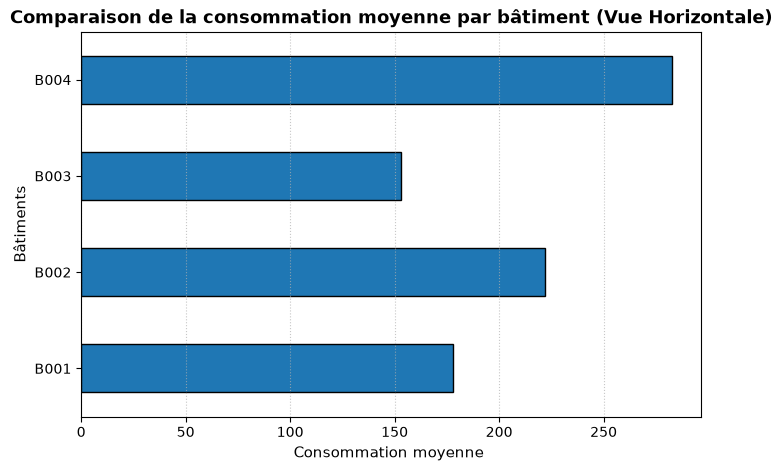

In [180]:
plt.figure(figsize=(8, 5))

# Tracé du diagramme en barres horizontales
consommation_batiment.plot(kind='barh', edgecolor='black')

# Personnalisation
plt.title("Comparaison de la consommation moyenne par bâtiment (Vue Horizontale)", fontsize=13, fontweight='bold')
plt.ylabel("Bâtiments", fontsize=11)
plt.xlabel("Consommation moyenne ", fontsize=11)
plt.grid(True, axis='x', linestyle=':', alpha=0.7)  # Grille uniquement verticale

plt.show()

 
### 4. Dans quels cas un graphique horizontal peut-il être plus lisible ?

**Explication :**
Un graphique en barres horizontales est préférable dans deux scénarios majeurs :
1. **Noms de catégories longs** : Si les labels des catégories contiennent du texte long (ex: "Bâtiment de recherche - Zone Nord"), ils se lisent de gauche à droite naturellement, alors que sur un axe vertical, ils se chevauchent ou doivent être écrits de biais.
2. **Grand nombre de catégories** : Lorsqu'il y a 15 ou 20 catégories à comparer, la lecture de haut en bas est bien plus confortable pour l'œil humain.

## Partie 3 – Histogramme 
### 1. Afficher la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille

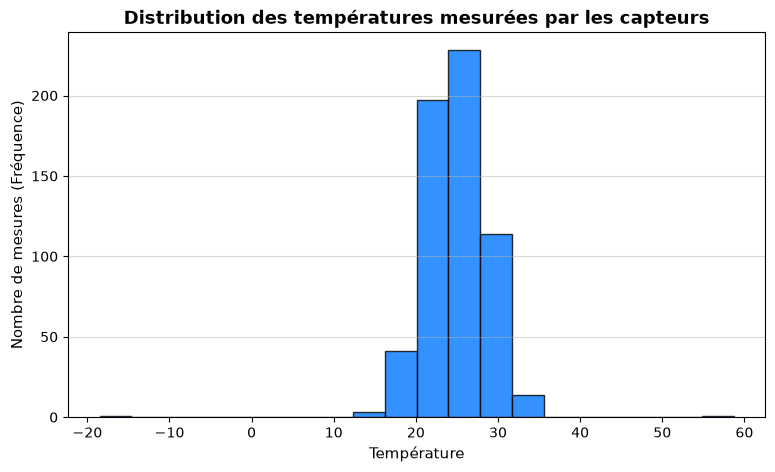

In [181]:
plt.figure(figsize=(9, 5))

# Tracé de l'histogramme de température avec 20 bins (en supprimant les valeurs manquantes avec .dropna())
plt.hist(df['temperature'].dropna(), bins=20, color="#0077ff", edgecolor='black', alpha=0.8)

# Habillage graphique
plt.title("Distribution des températures mesurées par les capteurs", fontsize=13, fontweight='bold')
plt.xlabel("Température", fontsize=11)
plt.ylabel("Nombre de mesures (Fréquence)", fontsize=11)
plt.grid(True, axis='y', alpha=0.5)  # Uniquement les grilles horizontales (Y)

plt.show()

### 2. Analyser le graphique pour voir 
L'analyse de cet histogramme nous montre :
#### a. où se concentrent les températures:
 Les températures se concentrent très majoritairement dans une plage comprise entre **20  et 30**.
#### b. si la distribution semble symétrique :
 La distribution est globalement **symétrique** et prend une forme classique de "cloche" (loi normale) centrée autour de sa moyenne/médiane de **24.8**.
#### c. s'il existe des valeurs très éloignées: 
On distingue clairement à l'œil nu deux petites barres complètement isolées à l'extrême gauche  et à l'extrême droite. Ce sont nos deux anomalies matérielles qui se détachent du comportement global du réseau.
#### d. si des valeurs aberrantes sont visibles : 
Il ya des valeurs aberantes visibles (**-18.5**) et (**58.7C**)

### 3. Afficher la distribution de la consommation en divisant la plage des données en 20 classes

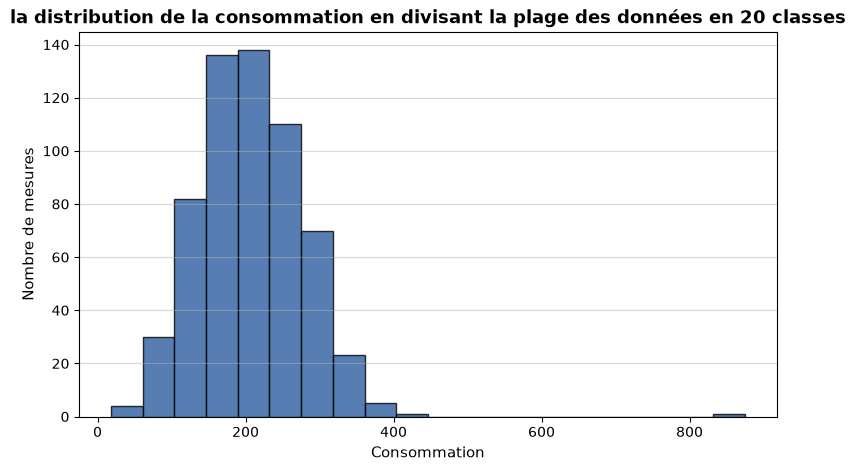

In [182]:
plt.figure(figsize=(9, 5))
plt.hist(df['consommation'].dropna(), bins=20, color="#2c5ea0", edgecolor='black', alpha=0.8)
plt.title('la distribution de la consommation en divisant la plage des données en 20 classes', fontsize=13, fontweight='bold')
plt.xlabel('Consommation', fontsize=11)
plt.ylabel('Nombre de mesures', fontsize=11)
plt.grid(True, axis='y', alpha=0.5)
plt.show()

### a. Modifier le nombre de classes à 10

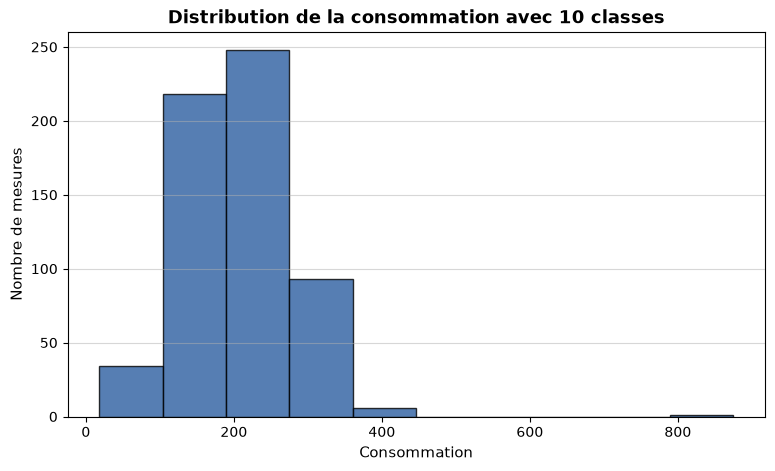

In [183]:
plt.figure(figsize=(9, 5))
plt.hist(df['consommation'].dropna(), bins=10, color="#2c5ea0", edgecolor='black', alpha=0.8)
plt.title('Distribution de la consommation avec 10 classes', fontsize=13, fontweight='bold')
plt.xlabel('Consommation', fontsize=11)
plt.ylabel('Nombre de mesures', fontsize=11)
plt.grid(True, axis='y', alpha=0.5)
plt.show()

### b. Modifier le nombre de classes à 30

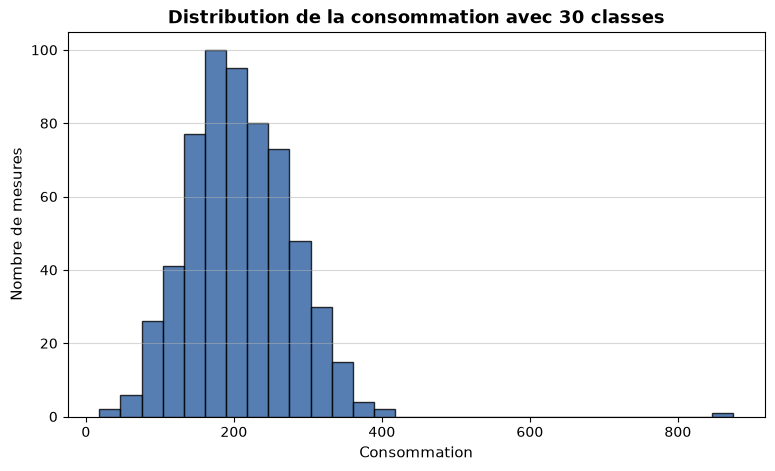

In [184]:
plt.figure(figsize=(9, 5))
plt.hist(df['consommation'].dropna(), bins=30, color="#2c5ea0", edgecolor='black', alpha=0.8)
plt.title('Distribution de la consommation avec 30 classes', fontsize=13, fontweight='bold')
plt.xlabel('Consommation', fontsize=11)
plt.ylabel('Nombre de mesures', fontsize=11)
plt.grid(True, axis='y', alpha=0.5)
plt.show()

### c. Quel impact le nombre de classes a-t-il sur l'interprétation ?

#### Le nombre de classes influence directement l’interprétation du graphique : avec peu de classes, la distribution paraît plus simple, mais certains détails peuvent être masqués ; avec beaucoup de classes, on voit plus de détails, mais le graphique devient plus bruité et plus difficile à lire. Un nombre modéré de classes offre le meilleur compromis entre lisibilité et précision.

## Partie 4 – Nuage de points (Scatter Plot) 
### 1. Réaliser un nuage de points entre température et consommation

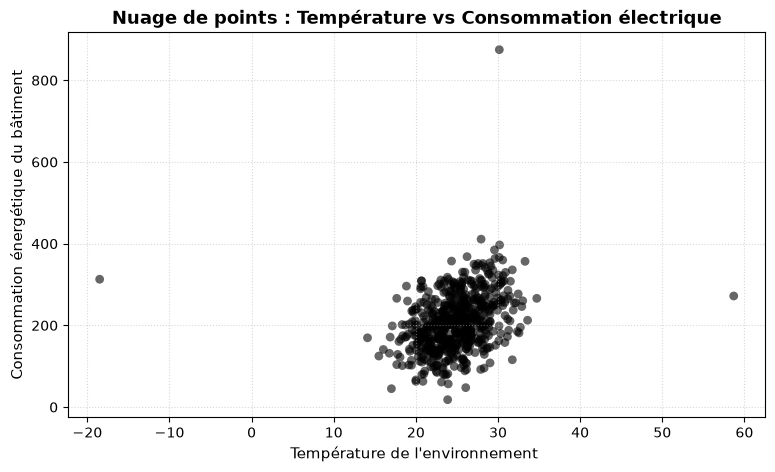

In [185]:
plt.figure(figsize=(9, 5))
plt.scatter(df['temperature'], df['consommation'], color="#000000", alpha=0.6, edgecolor='none', s=40)
plt.title("Nuage de points : Température vs Consommation électrique", fontsize=13, fontweight='bold')
plt.xlabel("Température de l'environnement ", fontsize=11)
plt.ylabel("Consommation énergétique du bâtiment", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

### 2. Déterminer visuellement s'il semble exister une relation entre les deux

Il existe donc une **relation linéaire positive modérée** : quand la température grimpe, la consommation énergétique a tendance à croître.

## Partie 5 – Diagramme à moustache (Box plot) 
### 1. Créer un box plot de la température. N’oublier pas de supprimer les valeurs manquantes avant de construire le graphique et afficher uniquement les lignes horizontales de la grille

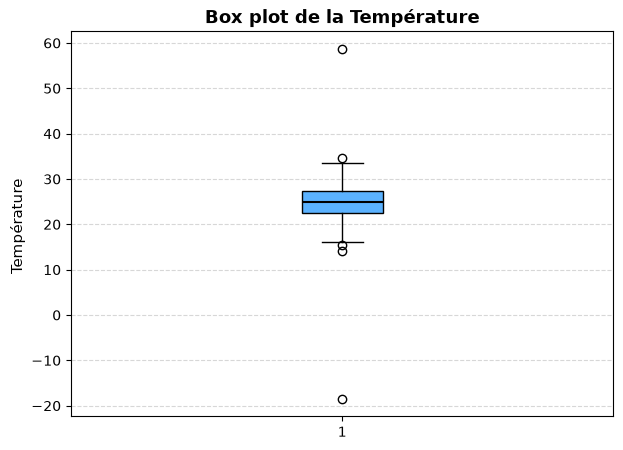

In [186]:
plt.figure(figsize=(7, 5))

# Tracé du boxplot pour la température en éliminant les valeurs manquantes pour éviter les erreurs
plt.boxplot(df['temperature'].dropna(), patch_artist=True, 
            boxprops=dict(facecolor="#5BB2FF", color='black'),
            medianprops=dict(color='black', linewidth=1.5))
plt.title("Box plot de la Température", fontsize=13, fontweight='bold')
plt.ylabel("Température ", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)  # Grille horizontale uniquement
plt.show()

### 2. Que représentent les points situés en dehors des moustaches ?

Les points situés en dehors des moustaches représentent des valeurs atypiques, aussi appelées outliers. Ils correspondent à des mesures nettement plus faibles ou plus élevées que la majorité des données, et peuvent signaler une anomalie de mesure, un capteur défectueux ou un événement particulier.

### 3. Créer un box plot de la consommation

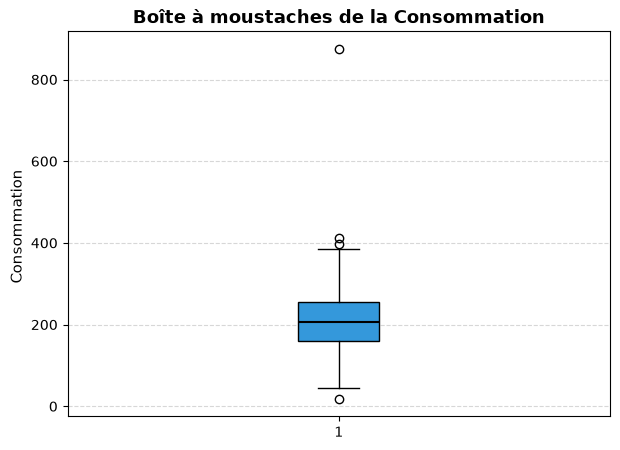

In [187]:
plt.figure(figsize=(7, 5))

# Tracé de la boîte à moustache pour la consommation
plt.boxplot(df['consommation'].dropna(), patch_artist=True, 
            boxprops=dict(facecolor='#3498db', color='black'),
            medianprops=dict(color='black', linewidth=1.5))

plt.title("Boîte à moustaches de la Consommation", fontsize=13, fontweight='bold')
plt.ylabel("Consommation ", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

### 4. A partir des deux box plot, comparer


- **a) la position de la médiane** : La température a une médiane centrale très stable (à **24.86**). Pour la consommation, la médiane se situe à **206.15**.
- **b) Taille de la boîte** : La boîte de la température est très étroite (IQR = **4.71 °C**, allant de 22.57 à 27.28). La boîte de consommation, en revanche, est très étalée (IQR = **93.95 kWh**, allant de 160.18 à 254.13).
- **c) Longueur des moustaches** : Les moustaches de température s'arrêtent vers 16  et 34, tandis que celles de la consommation couvrent une plage beaucoup plus large de valeurs réelles (de 20 à près de 380 ).
- **d) Valeurs extrêmes** : La température montre des outliers de part et d'autre (froid et chaud extrême). La consommation présente une anomalie positive énorme de **875** (mesure `M0416` en erreur).

### 5. La consommation présente-t-elle davantage de dispersion que la température ?

Oui, la consommation présente davantage de dispersion que la température. Sa boîte à moustaches est beaucoup plus large, ses moustaches s’étendent sur une plage plus grande et ses valeurs extrêmes sont plus marquées, ce qui montre une variabilité plus forte d’une mesure à l’autre.

## Partie 6 – Diagramme circulaire (Pie Chart) 
### 1. Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR)

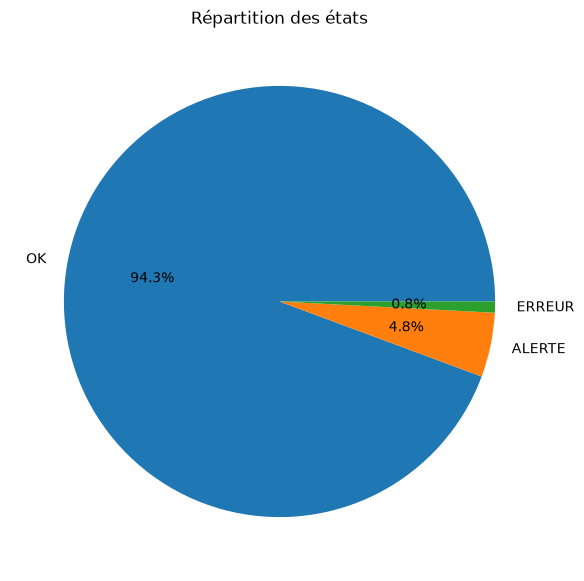

In [188]:
# Calcul de l'effectif pour chaque état
etats = df['etat'].dropna().value_counts()
plt.figure(figsize=(7, 7))
# Tracé du diagramme circulaire
plt.pie(etats, labels=etats.index, autopct='%1.1f%%') 
plt.title("Répartition des états")
plt.show()

### 2. interpréter la proportion de capteurs OK ; proportion ALERTE ; proportion ERREUR

L'analyse des proportions montre que :
1. **OK (94.3 %)** : Une très large majorité de notre parc fonctionne de manière normale.
2. **ALERTE (4.8 %)** : Près de 5 % des mesures sont en alerte (dépassements de seuils temporaires). 
3. **ERREUR (0.8 %)** : Moins de 1 % des mesures sont en erreur de relevé, illustrant l'excellente fiabilité physique globale de l'installation.

### Partie 7 : Plusieurs courbes sur un même graphique 
**Construire sur un même graphique « Évolution de la température par bâtiment" » des quatre 
bâtiments**.

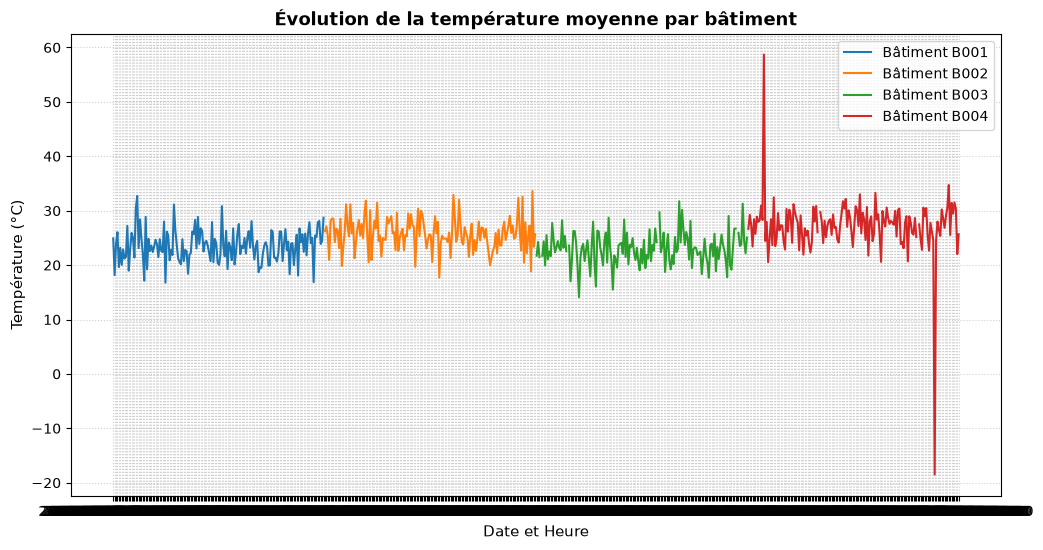

In [189]:
plt.figure(figsize=(12, 6))

# Tri chronologique pour le tracé temporel
df_tri = df.sort_values('date_heure')

# Boucle pour tracer chaque bâtiment
for bat in sorted(df_tri['batiment'].unique()):
    df_bat = df_tri[df_tri['batiment'] == bat]
    # Groupement par date pour lisser et obtenir un tracé propre
    df_bat_temp = df_bat.groupby('date_heure')['temperature'].mean().reset_index()
    plt.plot(df_bat_temp['date_heure'], df_bat_temp['temperature'], label=f"Bâtiment {bat}", linewidth=1.5)

# Habillage du graphique à plusieurs courbes
plt.title("Évolution de la température moyenne par bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Date et Heure", fontsize=11)
plt.ylabel("Température (°C)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()  # Affichage de la légende pour identifier chaque bâtiment

plt.show()

## Partie 8 : Sauvegarde des graphiques 
### 1. Sauvegarder le graphique sur l'évolution de la température en fonction du temps dans exports/ temperature.png

In [190]:
# Réinitialisation et création du graphique temporel à sauvegarder
plt.figure(figsize=(10, 5))
plt.plot(df['date_heure'], df['temperature'], color='red', label='Température Moyenne')
plt.title("Évolution globale de la température en fonction du temps")
plt.xlabel("Date et Heure")
plt.ylabel("Température ")
plt.grid(True)
plt.legend()
# Sauvegarde au format PNG dans le dossier d'export
plt.savefig('../exports/temperature.png', bbox_inches='tight', dpi=150)
plt.close()  # plt.close() évite de surcharger l'affichage mémoire du notebook
print("Graphique PNG sauvegardé avec succès !")

Graphique PNG sauvegardé avec succès !


### 2. Sauvegarder le graphique sur l'évolution de la température en fonction du temps dans exports/ temperature.pdf

In [191]:
# Recréation de la figure pour l'export PDF
plt.figure(figsize=(10, 5))
plt.plot(df['date_heure'], df['temperature'], color='red', label='Température Moyenne')
plt.title("Évolution globale de la température en fonction du temps")
plt.xlabel("Date et Heure")
plt.ylabel("Température (°C)")
plt.grid(True)
plt.legend()

# Sauvegarde au format PDF
plt.savefig('../exports/temperature.pdf', bbox_inches='tight')
plt.close()
print("Graphique PDF sauvegardé avec succès !")

Graphique PDF sauvegardé avec succès !
